### Edible Plants Database EDA

#### Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset=pd.read_csv("data/edible_plants.csv")
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
0,Pisum sativum,Pea,Legume,Full sun,Very High,6.0,7.5,Medium,Loamy,Annual,Half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten..."
1,Phaseolus coccineus,Beans (Runner),Legume,Full sun,Medium,6.0,6.8,Medium,Loamy and clay,Annual,Tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar..."
2,Phaseolus vulgari,Beans (French),Legume,Full sun,Medium,6.0,7.5,Medium,Any well-drained and fertile,Annual,Tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar..."
3,Vicia faba,Beans (Broad),Legume,Full sun/partial shade/full shade,Very Low,6.0,7.0,Medium,Any well-drained and fertile,Annual,Hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...
4,Brassica oleracea,Cabbage (Spring),Legume,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...


In [4]:
dataset.describe()

,preferred_ph_lower,preferred_ph_upper,energy
count,140.000000,140.000000,12.000000
mean,5.832143,7.114286,35.666667
std,0.422440,0.476433,26.568379
min,4.500000,6.000000,0.000000
25%,5.500000,7.000000,26.500000
50%,6.000000,7.000000,31.000000
75%,6.000000,7.500000,38.750000
max,7.000000,8.500000,88.000000


In [5]:
dataset.dtypes

taxonomic_name                 str
common_name                    str
cultivation                    str
sunlight                       str
water                          str
preferred_ph_lower         float64
preferred_ph_upper         float64
nutrients                      str
soil                           str
season                         str
temperature_class              str
temperature_germination        str
temperature_growing            str
days_germination               str
days_harvest                   str
nutritional_info               str
energy                     float64
sensitivities                  str
description                    str
requirements                   str
dtype: object

In [6]:
dataset.columns

Index(['taxonomic_name', 'common_name', 'cultivation', 'sunlight', 'water',
       'preferred_ph_lower', 'preferred_ph_upper', 'nutrients', 'soil',
       'season', 'temperature_class', 'temperature_germination',
       'temperature_growing', 'days_germination', 'days_harvest',
       'nutritional_info', 'energy', 'sensitivities', 'description',
       'requirements'],
      dtype='str')

In [7]:
(dataset.isna().sum()/dataset.shape[0]) * 100

taxonomic_name              0.000000
common_name                 0.000000
cultivation                 0.000000
sunlight                    0.000000
water                       0.000000
preferred_ph_lower          0.000000
preferred_ph_upper          0.000000
nutrients                   0.000000
soil                       32.857143
season                     52.142857
temperature_class           0.000000
temperature_germination    25.714286
temperature_growing        58.571429
days_germination           27.142857
days_harvest               19.285714
nutritional_info           92.142857
energy                     91.428571
sensitivities              90.714286
description                 0.000000
requirements                0.000000
dtype: float64

#### Exploratory Data Analysis

##### Analyzing the cultivation feature column

In [8]:
dataset['cultivation'].value_counts()

cultivation
Miscellaneous     65
Brassica          21
Legume            10
Allium             9
Cucurbit           8
Umbelliferae       8
Solanaceae         6
Lamiaceae          4
Salad              3
Chenopodiaceae     3
Solanum            2
Brassicas          1
Name: count, dtype: int64

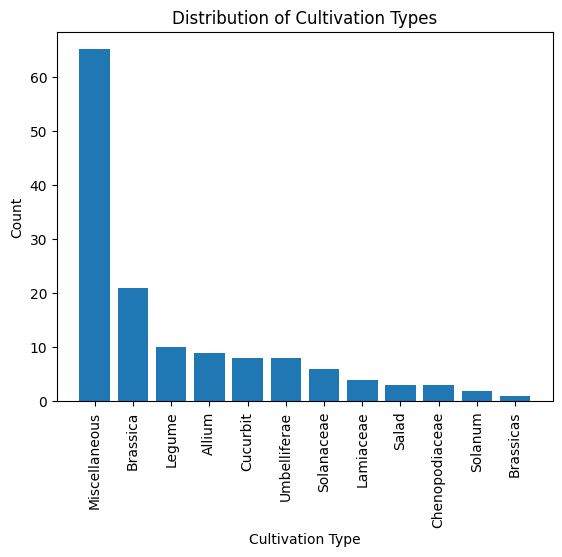

In [9]:
plt.bar(dataset['cultivation'].value_counts().index, dataset['cultivation'].value_counts().values)
plt.xlabel('Cultivation Type')
plt.ylabel('Count')
plt.title('Distribution of Cultivation Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the Sunlight Feature column

In [10]:
dataset['sunlight'].value_counts()

sunlight
Full sun                              87
Full sun/partial shade                44
Partial shade                          5
Full sun/partial shade/full shade      2
partial shade                          1
full sun/partial shade/ full shade     1
Name: count, dtype: int64

In [11]:
dataset['sunlight'] = dataset['sunlight'].str.lower()

In [12]:
dataset[dataset['sunlight']=='full sun/partial shade/ full shade']['sunlight']='full sun/partial shade/full shade'

C:\Users\aadit\AppData\Local\Temp\ipykernel_12440\2098468352.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  dataset[dataset['sunlight']=='full sun/partial shade/ full shade']['sunlight']='full sun/partial shade/full shade'


In [13]:
dataset['sunlight'].value_counts()

sunlight
full sun                              87
full sun/partial shade                44
partial shade                          6
full sun/partial shade/full shade      2
full sun/partial shade/ full shade     1
Name: count, dtype: int64

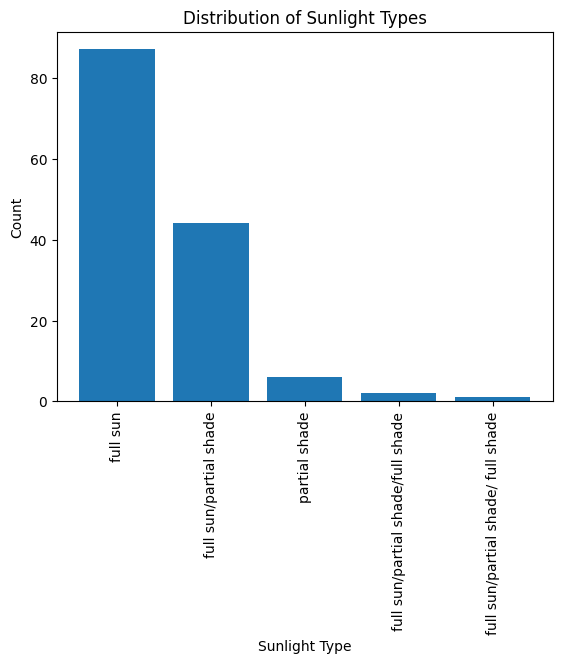

In [14]:
plt.bar(dataset['sunlight'].value_counts().index, dataset['sunlight'].value_counts().values)
plt.xlabel('Sunlight Type')
plt.ylabel('Count')
plt.title('Distribution of Sunlight Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the water feature column

In [15]:
dataset['water'].value_counts()

water
Medium       93
High         24
Low          18
Very High     1
Very Low      1
very high     1
Very low      1
high          1
Name: count, dtype: int64

In [16]:
dataset['water']=dataset['water'].str.lower()
dataset['water'].value_counts()

water
medium       93
high         25
low          18
very high     2
very low      2
Name: count, dtype: int64

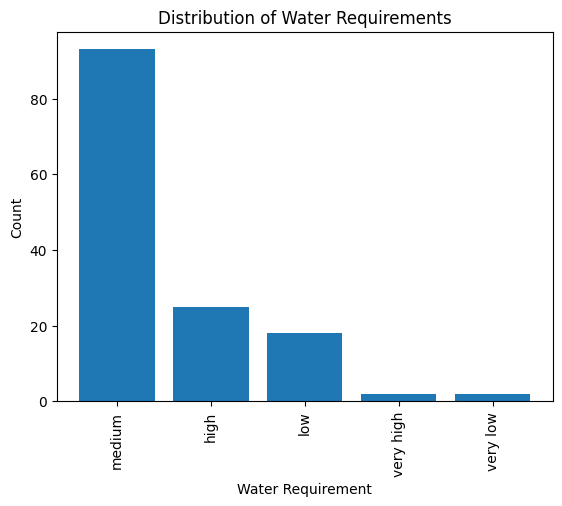

In [17]:
plt.bar(dataset['water'].value_counts().index, dataset['water'].value_counts().values)
plt.xlabel('Water Requirement')
plt.ylabel('Count')
plt.title('Distribution of Water Requirements')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the preferred ph_lower feature column

In [18]:
print(dataset['preferred_ph_lower'].value_counts())

preferred_ph_lower
6.0    77
5.5    39
6.5    10
5.0     9
7.0     3
4.5     2
Name: count, dtype: int64


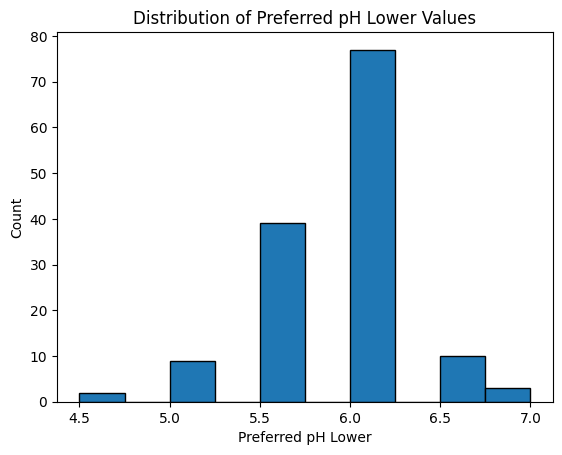

In [19]:
plt.hist(dataset['preferred_ph_lower'].dropna(), edgecolor='black')
plt.xlabel('Preferred pH Lower')
plt.ylabel('Count')
plt.title('Distribution of Preferred pH Lower Values')
plt.show()

##### Analyzing the preferred_ph_higher feature column

In [20]:
print(dataset['preferred_ph_upper'].value_counts())


preferred_ph_upper
7.0    69
7.5    41
6.5    10
6.0     9
8.0     7
8.5     2
6.8     1
6.7     1
Name: count, dtype: int64


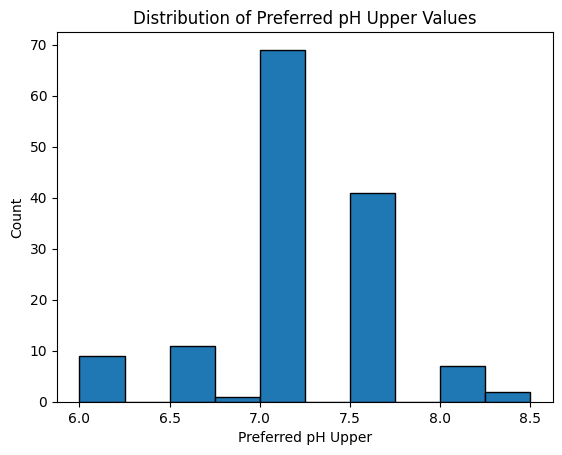

In [21]:
plt.hist(dataset['preferred_ph_upper'].dropna(), edgecolor='black')
plt.xlabel('Preferred pH Upper')
plt.ylabel('Count')
plt.title('Distribution of Preferred pH Upper Values')
plt.show()

##### Analyzing the nutrients feature column

In [22]:
dataset['nutrients'].value_counts()

nutrients
Medium                                      58
Low                                         48
High                                        28
High potassium fertiliser every 2 weeks.     2
low                                          2
high                                         1
Medium to high                               1
Name: count, dtype: int64

In [23]:
dataset['nutrients']=dataset['nutrients'].str.lower()
dataset.loc[dataset['nutrients']=='high potassium fertiliser every 2 weeks.','nutrients']='high'
dataset.loc[dataset['nutrients']=='medium to high','nutrients']='high'
dataset['nutrients'].value_counts()

nutrients
medium    58
low       50
high      32
Name: count, dtype: int64

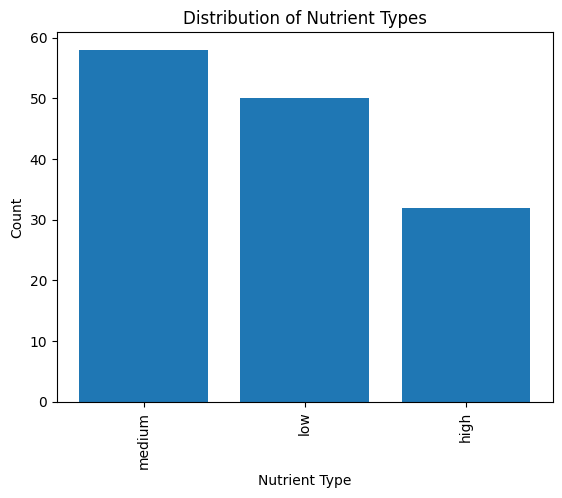

In [24]:
plt.bar(dataset['nutrients'].value_counts().index, dataset['nutrients'].value_counts().values)
plt.xlabel('Nutrient Type')
plt.ylabel('Count')
plt.title('Distribution of Nutrient Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the soil feature column

In [25]:
dataset['soil'].value_counts()

soil
Loamy                                                               20
Any well-drained and fertile                                         8
Sand/loam/clay                                                       7
Loamy and sandy                                                      7
Loam, Chalk, Sand                                                    7
Chalk, Clay, Sand, Loam                                              5
Loamy, clay and sandy                                                4
Loamy and clay                                                       3
Loam                                                                 3
Sandy                                                                2
Well-drained, fertile and high in organic matter. Loamy and clay     2
Loamy, sandy and silty                                               2
Loamy soil                                                           2
Loam, Sand                                                           2
S

In [26]:
dataset['soil']=dataset['soil'].str.lower()
dataset.loc[dataset['soil']=='any well-drained and fertile', 'soil']='well-drained and fertile'

##### Analyzing the season feature column

In [27]:
dataset['season'].value_counts()

season
Perennial                       37
Annual                          12
biennial                         8
biennial, grown as annual        2
perennial                        2
Perrenial                        1
Annual/perannial                 1
Biennial, grown as an annual     1
Shrub                            1
Perrenial evergreen              1
Semi-evergreen perrenial         1
Name: count, dtype: int64

In [28]:
dataset['season']=dataset['season'].str.lower()
dataset.loc[dataset['season']=='biennial, grown as an annual','season']='biennial, grown as annual'
dataset['season'] = dataset['season'].replace({
    'perrenial': 'perennial',
    'perrenial evergreen': 'perennial',
    'semi-evergreen perrenial': 'perennial',
    'annual/perannial': 'perennial',
    'biennial, grown as annual': 'biennial'
})
dataset['season'].value_counts()

season
perennial    43
annual       12
biennial     11
shrub         1
Name: count, dtype: int64

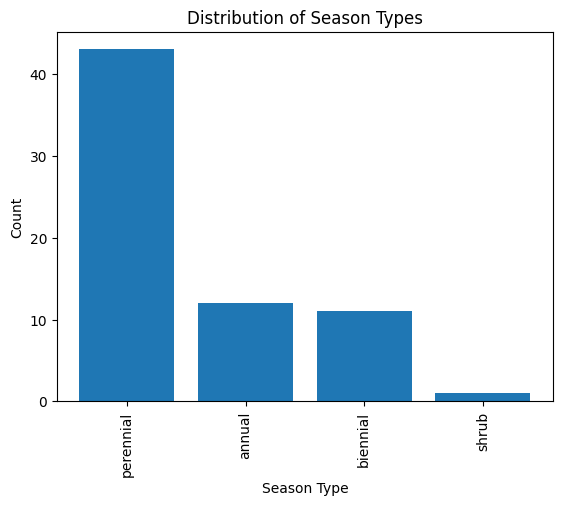

In [29]:
plt.bar(dataset['season'].value_counts().index, dataset['season'].value_counts().values)
plt.xlabel('Season Type')
plt.ylabel('Count')
plt.title('Distribution of Season Types')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the temperature class column

In [30]:
dataset['temperature_class'].value_counts()

temperature_class
Hardy          67
Tender         37
Very hardy     21
Half hardy     12
Very tender     2
Very hard       1
Name: count, dtype: int64

In [31]:
dataset['temperature_class']=dataset['temperature_class'].str.lower()
dataset.loc[dataset['temperature_class']=='very hard', 'temperature_class']='very hardy'
dataset['temperature_class'].value_counts()

temperature_class
hardy          67
tender         37
very hardy     22
half hardy     12
very tender     2
Name: count, dtype: int64

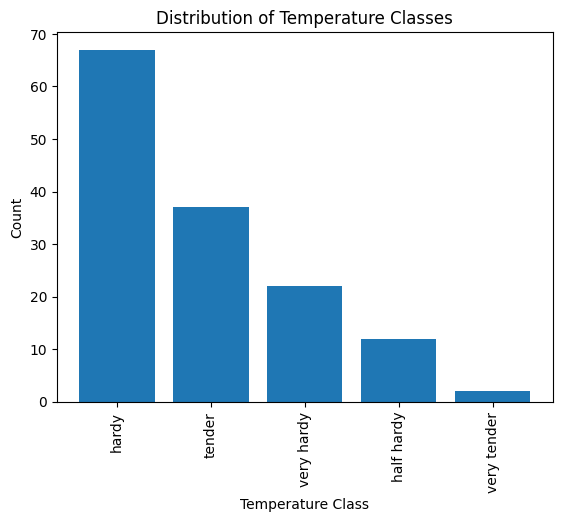

In [32]:
plt.bar(dataset['temperature_class'].value_counts().index, dataset['temperature_class'].value_counts().values)
plt.xlabel('Temperature Class')
plt.ylabel('Count')
plt.title('Distribution of Temperature Classes')
plt.xticks(rotation=90)
plt.show()

##### Analyzing the temperature germination feature column

In [33]:
dataset['temperature_germination'].describe()

count                 104
unique                 20
top       Not applicable.
freq                   30
Name: temperature_germination, dtype: object

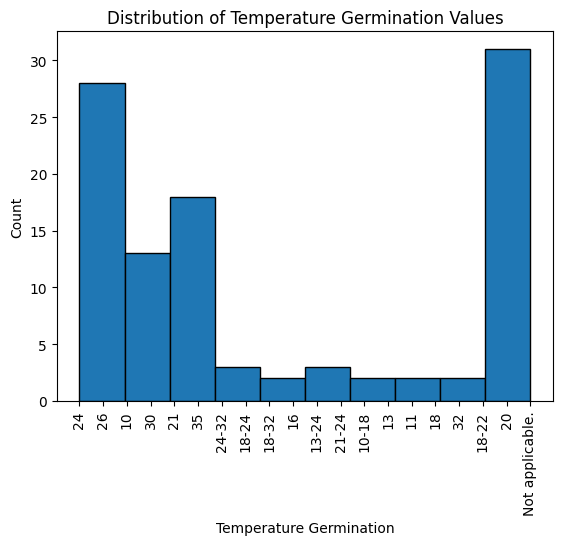

In [34]:
plt.hist(dataset['temperature_germination'].dropna(), edgecolor='black')
plt.xlabel('Temperature Germination')
plt.ylabel('Count')
plt.title('Distribution of Temperature Germination Values')
plt.xticks(rotation=90)
plt.show()

#### Analyzing the temperature growing feature column

In [35]:
dataset[['min_temperature_growing',
         'max_temperature_growing']] = \
dataset['temperature_growing'].str.split('-', expand=True)

dataset['min_temperature_growing']=dataset['min_temperature_growing'].str.strip()
dataset['min_temperature_growing']=pd.to_numeric(dataset['min_temperature_growing'], errors='coerce')
dataset['max_temperature_growing']=dataset['max_temperature_growing'].str.strip()
dataset['max_temperature_growing']=pd.to_numeric(dataset['max_temperature_growing'], errors='coerce')
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,...,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,...,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,...,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,...,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,...,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,...,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0


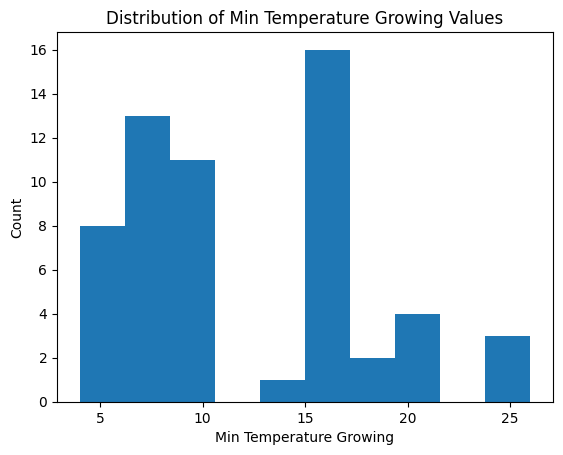

In [36]:
plt.hist(dataset['min_temperature_growing'])
plt.xlabel('Min Temperature Growing')
plt.ylabel('Count')
plt.title('Distribution of Min Temperature Growing Values')
plt.show()

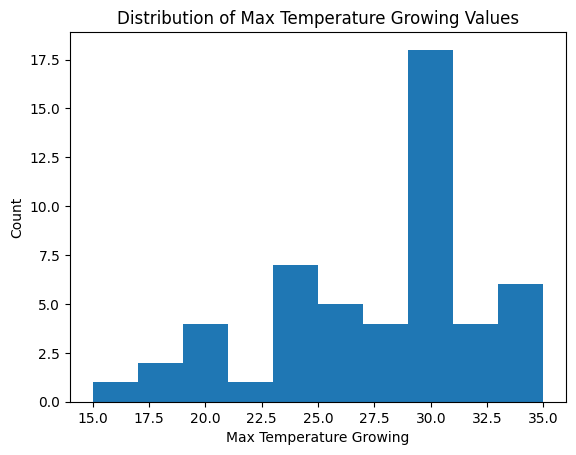

In [37]:
plt.hist(dataset['max_temperature_growing'])
plt.xlabel('Max Temperature Growing')
plt.ylabel('Count')
plt.title('Distribution of Max Temperature Growing Values')
plt.show()

In [38]:
pd.options.display.max_columns = None
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0


##### Analyzing the Days of Germination feature column

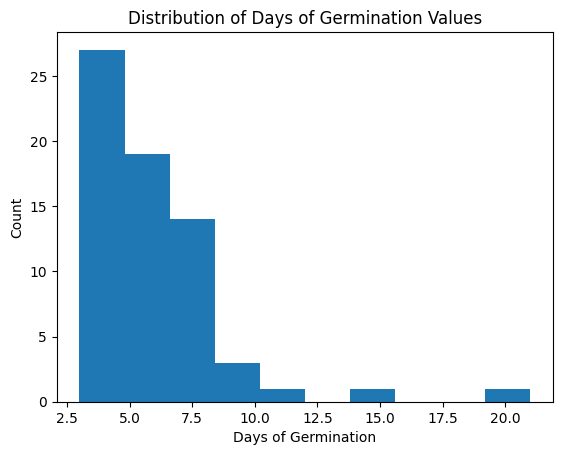

In [39]:
dataset['days_germination']=dataset['days_germination'].str.strip()
dataset['days_germination']=pd.to_numeric(dataset['days_germination'], errors='coerce')
plt.hist(dataset['days_germination'])
plt.xlabel('Days of Germination')
plt.ylabel('Count')
plt.title('Distribution of Days of Germination Values')
plt.show()

##### Analyzing the days to harvest feature column

In [40]:
dataset[['min_days_harvest',
         'max_days_harvest']] = \
dataset['days_harvest'].str.split('-', expand=True)

dataset['min_days_harvest']=dataset['min_days_harvest'].str.strip()
dataset['min_days_harvest']=pd.to_numeric(dataset['min_days_harvest'], errors='coerce')
dataset['max_days_harvest']=dataset['max_days_harvest'].str.strip()
dataset['max_days_harvest']=pd.to_numeric(dataset['max_days_harvest'], errors='coerce')
dataset.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements,min_temperature_growing,max_temperature_growing,min_days_harvest,max_days_harvest
0,Pisum sativum,Pea,Legume,full sun,very high,6.0,7.5,medium,loamy,annual,half hardy,24,4-24,6.0,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten...",4.0,24.0,55.0,75.0
1,Phaseolus coccineus,Beans (Runner),Legume,full sun,medium,6.0,6.8,medium,loamy and clay,annual,tender,26,16-30,7.0,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar...",16.0,30.0,65.0,85.0
2,Phaseolus vulgari,Beans (French),Legume,full sun,medium,6.0,7.5,medium,well-drained and fertile,annual,tender,26,16-30,7.0,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar...",16.0,30.0,40.0,55.0
3,Vicia faba,Beans (Broad),Legume,full sun/partial shade/full shade,very low,6.0,7.0,medium,well-drained and fertile,annual,hardy,10,8-15,7.0,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...,8.0,15.0,85.0,115.0
4,Brassica oleracea,Cabbage (Spring),Legume,full sun,high,6.0,7.5,high,sand/loam/clay,biennial,hardy,26,7-30,4.0,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...,7.0,30.0,55.0,85.0


##### Analyzing the energy feature column

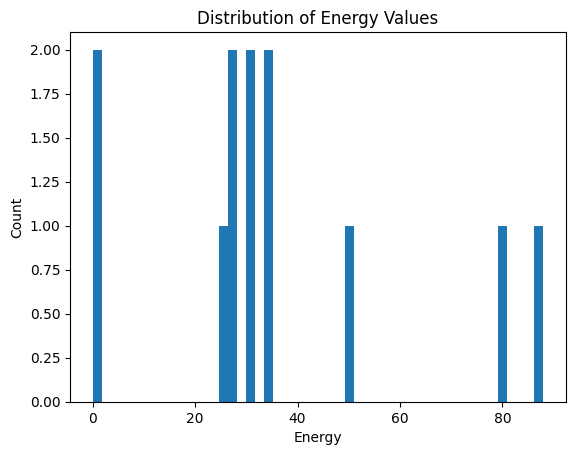

In [41]:
plt.hist(dataset['energy'],bins=50)
plt.xlabel('Energy')
plt.ylabel('Count')
plt.title('Distribution of Energy Values')
plt.show()

In [42]:
dataset['energy'].value_counts()

energy
27.0    2
31.0    2
0.0     2
80.0    1
88.0    1
25.0    1
34.0    1
35.0    1
50.0    1
Name: count, dtype: int64

In [43]:
dataset.isna().sum()

taxonomic_name               0
common_name                  0
cultivation                  0
sunlight                     0
water                        0
preferred_ph_lower           0
preferred_ph_upper           0
nutrients                    0
soil                        46
season                      73
temperature_class            0
temperature_germination     36
temperature_growing         82
days_germination            74
days_harvest                27
nutritional_info           129
energy                     128
sensitivities              127
description                  0
requirements                 0
min_temperature_growing     82
max_temperature_growing     88
min_days_harvest            59
max_days_harvest            71
dtype: int64

##### Analyzing the nutritional info feature column

In [44]:
dataset['nutritional_info']

0      A good source of vitamin K, manganese, and die...
1      A good source of protein, thiamine, and ribofl...
2      A good source of protein, thiamine, and ribofl...
3      A good source of vitamin-B6 (pyridoxine), thia...
4      A very good source of manganese, dietary fibre...
                             ...                        
135                                                  NaN
136                                                  NaN
137                                                  NaN
138                                                  NaN
139                                                  NaN
Name: nutritional_info, Length: 140, dtype: str

In [45]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
dataset['requirements']

0                                                                                                                                                                                                          Require a sunny, nutrient-rich, moisture-retentive site.
1                                                                                                    Beans are a tender, warm-weather crop. They are perfectly suited to a sunny, and well-drained spot away from strong winds. They enjoy moist, and fertile soil.
2                                                                                                    Beans are a tender, warm-weather crop. They are perfectly suited to a sunny, and well-drained spot away from strong winds. They enjoy moist, and fertile soil.
3                                                                                                                 Broad beans are a cool weather crop. They grow best in a sunny, and well drained spot away from strong win

In [46]:
dataset['description']

0                                                                                                                                                           The pea is the small spherical seed, or the seed-pod. Peas come in two varieties: shelling, and mangetout.
1                                                                                                           Runner bean plants are more productive than green bean plants. The rough, flat, green pods need to be destrung and cut into smaller pieces before cooking.
2                                                                                                                                                                      French beans are the unripe fruit, and protective pods of various cultivars of the common bean.
3                                                                                                                                                 Broad beans - also known as the fava bean - are large, broad pods

#### Analyzing the sensitivities feature column

In [47]:
dataset.isna().sum()

taxonomic_name               0
common_name                  0
cultivation                  0
sunlight                     0
water                        0
preferred_ph_lower           0
preferred_ph_upper           0
nutrients                    0
soil                        46
season                      73
temperature_class            0
temperature_germination     36
temperature_growing         82
days_germination            74
days_harvest                27
nutritional_info           129
energy                     128
sensitivities              127
description                  0
requirements                 0
min_temperature_growing     82
max_temperature_growing     88
min_days_harvest            59
max_days_harvest            71
dtype: int64

In [48]:
dataset['sensitivities'].value_counts()

sensitivities
Drought intolerant                                                                                                                               4
Particularly vulnerable to pests. Do not grow if soil is too acidic.                                                                             1
A cool weather crop best not grown over hot summer months. Broccoli are temperature sensitive with an ideal temperature range of 18 to 26 °C.    1
Affected by a wide range of pests and diseases. Drought intolerant.                                                                              1
Sensitive to temperatures over 25 °C.                                                                                                            1
Heat intolerant                                                                                                                                  1
A cool weather crop best not grown over hot summer months.                                              

#### Now we will try to analyze the missing values in each feature column and try to impute the sensible values wherever possible

In [49]:
dataset.isna().sum()

taxonomic_name               0
common_name                  0
cultivation                  0
sunlight                     0
water                        0
preferred_ph_lower           0
preferred_ph_upper           0
nutrients                    0
soil                        46
season                      73
temperature_class            0
temperature_germination     36
temperature_growing         82
days_germination            74
days_harvest                27
nutritional_info           129
energy                     128
sensitivities              127
description                  0
requirements                 0
min_temperature_growing     82
max_temperature_growing     88
min_days_harvest            59
max_days_harvest            71
dtype: int64

In [50]:
dataset['soil']

0                                                                 loamy
1                                                        loamy and clay
2                                              well-drained and fertile
3                                              well-drained and fertile
4                                                        sand/loam/clay
5                                                       loamy and sandy
6                                                                 loamy
7                                              well-drained and fertile
8                                                                 loamy
9                                                                 loamy
10                                             well-drained and fertile
11                                             well-drained and fertile
12                                                                loamy
13                                             well-drained and 

In [51]:
dataset['soil'].value_counts()

soil
loamy                                                               20
well-drained and fertile                                             9
sand/loam/clay                                                       7
loamy and sandy                                                      7
loam, chalk, sand                                                    7
chalk, clay, sand, loam                                              5
loamy, clay and sandy                                                4
loamy and clay                                                       3
loam                                                                 3
sandy                                                                2
well-drained, fertile and high in organic matter. loamy and clay     2
loamy, sandy and silty                                               2
loamy soil                                                           2
loam, sand                                                           2
s

#### we will use the AgriBERT model to do this task

In [52]:
dataset["text"] = (
    dataset["description"].fillna("") + " " +
    dataset["requirements"].fillna("")
)

dataset["text"] = dataset["text"].str.strip()

In [53]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME = "recobo/agriBERT"   # example placeholder

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

c:\Users\aadit\Anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: recobo/agriBERT is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
def get_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :]

    return cls_embedding.squeeze().cpu().numpy()


In [ ]:
from tqdm import tqdm
import numpy as np

embeddings = []

for text in tqdm(dataset["text"]):
    emb = get_embedding(text)
    embeddings.append(emb)

embeddings = np.vstack(embeddings)

In [ ]:
embeddings.shape

In [ ]:
target_col = "soil"

train_idx = dataset[dataset[target_col].notna()].index
test_idx  = dataset[dataset[target_col].isna()].index

X_train = embeddings[train_idx]
y_train = dataset.loc[train_idx, target_col]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)


In [ ]:
X_test = embeddings[test_idx]

preds = clf.predict(X_test)

dataset.loc[test_idx, target_col] = preds


#### Do plants that require more sunlight also require higher temperatures?

##### What cultivation classes require the most water?